# 勇者傳說 — Monster V3 Generator (Blacklist Regeneration)

Regenerate **18 blacklisted monsters** that had bad quality in V1/V2. Uses improved prompts + higher steps/guidance.

**Targets** (from `AI_CONTENT_BLACKLIST`): bat, bear, dark_knight, demon_soldier, flower, ghost, goblin, insect, knight, mushroom, shark, skeleton, slime, wolf, worm, wolf_dire, wolf_ice, boss_forge_master


## 1. Setup

In [5]:
!pip install -q "numpy<2" scipy
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime

import gc, json, os, time
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')
MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')

for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

import torch
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    vram = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
    DEVICE = 'cuda'
    DTYPE = torch.float16
    print(f'GPU: {name} ({vram:.1f} GB VRAM)')
else:
    DEVICE = 'cpu'
    DTYPE = torch.bfloat16
    print('WARNING: No GPU! Generation will be very slow.')

print(f'Output: {OUTPUT_BASE}')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.0 requires numpy>=2.0

## 2. Utilities

In [6]:
class ProgressTracker:
    def __init__(self, task_name, output_dir):
        self.file = Path(output_dir) / f'_progress_{task_name}.json'
        self.completed = set()
        self.start_time = time.time()
        if self.file.exists():
            try:
                data = json.loads(self.file.read_text())
                self.completed = set(data.get('completed', []))
                print(f'[resume] {len(self.completed)} items already done')
            except Exception:
                pass

    def is_done(self, name): return name in self.completed

    def mark_done(self, name):
        self.completed.add(name)
        self.file.parent.mkdir(parents=True, exist_ok=True)
        self.file.write_text(json.dumps({
            'completed': sorted(self.completed),
            'count': len(self.completed),
            'last_updated': time.strftime('%Y-%m-%d %H:%M:%S'),
        }, indent=2))

    def summary(self, total):
        done = len(self.completed)
        elapsed = time.time() - self.start_time
        if done > 0:
            remaining = (total - done) * (elapsed / done)
            return f'{done}/{total} done, ~{remaining/60:.0f} min remaining'
        return f'0/{total} done'


def free_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def print_vram():
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated(0) / 1024**3
        props = torch.cuda.get_device_properties(0)
        total = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
        print(f'[vram] {used:.1f}/{total:.1f} GB')

## 3. Prompt Data

In [7]:
PROMPTS = {
  "_meta": {
    "style_prefix_xl": "16-bit JRPG pixel art, Dragon Quest style, masterpiece quality",
    "style_suffix_monster_xl": "single creature centered, dark background, clean edges, detailed sprite, solid opaque body",
    "negative_prompt_xl": "blurry, text, watermark, signature, duplicate, pair, group, multiple creatures, human, realistic photo"
  },
  "blacklist_v3": [
    {
      "name": "mon_bat",
      "prompt_xl": "ONE single dark purple vampire bat, large outstretched leathery wings with visible bone structure, solid dense furry body, glowing red eyes, small fangs, mid-flight pose, fully opaque silhouette, no transparency",
      "negative_prompt_extra": "transparent, see-through, multiple bats, sprite sheet",
      "size": 192,
      "steps_xl": 26,
      "guidance_xl": 7.5
    },
    {
      "name": "mon_bear",
      "prompt_xl": "ONE single massive dire bear monster, thick dark brown fur, solid muscular body, sharp claws, scarred grizzly, aggressive stance, single creature only no duplicates",
      "negative_prompt_extra": "multiple bears, sprite sheet, grid, four creatures",
      "size": 192,
      "steps_xl": 26,
      "guidance_xl": 7.5
    },
    {
      "name": "mon_dark_knight",
      "prompt_xl": "ONE single dark death knight, full solid black plate armor, purple glowing visor, massive purple greatsword, flowing dark cape, imposing complete figure, opaque armor no fragments",
      "negative_prompt_extra": "transparent, fragment, partial, scattered",
      "size": 192,
      "steps_xl": 26,
      "guidance_xl": 7.5
    },
    {
      "name": "mon_demon_soldier",
      "prompt_xl": "ONE single demon soldier, solid dark spiked black armor, curved horns, blazing red eyes, jagged dark sword, complete armored figure, fully visible opaque",
      "negative_prompt_extra": "transparent, see-through, ghostly",
      "size": 192,
      "steps_xl": 26,
      "guidance_xl": 7.5
    },
    {
      "name": "mon_flower",
      "prompt_xl": "ONE single carnivorous plant monster, massive venus flytrap head with sharp teeth, solid dark red-purple petals, thick thorny green stem, solid opaque plant body",
      "negative_prompt_extra": "transparent, see-through, wilted",
      "size": 192,
      "steps_xl": 26,
      "guidance_xl": 7.5
    },
    {
      "name": "mon_goblin",
      "prompt_xl": "ONE single small green goblin, solid warty green skin, oversized pointed ears, yellow eyes, wooden club, ragged loincloth, hunched stance, fully visible creature",
      "negative_prompt_extra": "transparent, tiny, fragment",
      "size": 192,
      "steps_xl": 26,
      "guidance_xl": 7.5
    },
    {
      "name": "mon_mushroom",
      "prompt_xl": "ONE single angry mushroom creature, large solid red cap with white polka dots, thick stem, stubby legs, squinting eyes, green spore cloud, opaque fungal body",
      "negative_prompt_extra": "transparent, see-through",
      "size": 192,
      "steps_xl": 26,
      "guidance_xl": 7.5
    },
    {
      "name": "mon_shark",
      "prompt_xl": "ONE single great white shark, sleek solid grey body, tall dorsal fin, gaping jaws with razor teeth, glowing red eyes, powerful predator, fully opaque body",
      "negative_prompt_extra": "transparent, see-through",
      "size": 192,
      "steps_xl": 26,
      "guidance_xl": 7.5
    },
    {
      "name": "mon_ghost",
      "prompt_xl": "ONE single floating ghost spirit, amorphous wispy white-blue glowing shape, hollow dark eyes, wailing mouth, spectral form dissolving into mist, NOT human NOT robed figure, ethereal blob creature",
      "negative_prompt_extra": "human, humanoid, robed figure, cat, animal, mammal, portrait",
      "size": 192,
      "steps_xl": 26,
      "guidance_xl": 7.5
    },
    {
      "name": "mon_knight",
      "prompt_xl": "ONE single corrupted dark knight monster, complete figure in dented black armor, tattered red cape, cursed glowing sword, undead warrior, full body visible",
      "negative_prompt_extra": "scattered items, icons, shield fragments, multiple objects",
      "size": 192,
      "steps_xl": 26,
      "guidance_xl": 7.5
    },
    {
      "name": "mon_skeleton",
      "prompt_xl": "ONE single undead skeleton warrior, complete bleached white bones, visible ribcage and skull, rusty sword, tattered armor remnants, glowing blue eye sockets, full figure",
      "negative_prompt_extra": "shield fragment, scattered bones, partial, icons",
      "size": 192,
      "steps_xl": 26,
      "guidance_xl": 7.5
    },
    {
      "name": "mon_slime",
      "prompt_xl": "iconic Dragon Quest blue slime, Akira Toriyama style, perfect teardrop shape, translucent gel body, two dot eyes, curved smile, isolated creature only, no background no buildings",
      "negative_prompt_extra": "building, architecture, house, background, landscape",
      "size": 192,
      "steps_xl": 26,
      "guidance_xl": 7.5
    },
    {
      "name": "mon_wolf",
      "prompt_xl": "ONE single fierce grey dire wolf, thick bristled silver-grey fur, bared sharp fangs, glowing yellow eyes, muscular body, aggressive stance, animal creature NOT human",
      "negative_prompt_extra": "human, humanoid, character, person",
      "size": 192,
      "steps_xl": 26,
      "guidance_xl": 7.5
    },
    {
      "name": "mon_insect",
      "prompt_xl": "ONE single large armored beetle monster, iridescent shell, sharp mandibles, segmented body, chitinous legs, single creature only",
      "negative_prompt_extra": "multiple beetles, sprite sheet, grid, four creatures",
      "size": 192,
      "steps_xl": 26,
      "guidance_xl": 7.5
    },
    {
      "name": "mon_worm",
      "prompt_xl": "ONE single giant worm centipede monster, segmented armored body, many legs, poison mandibles, burrowing pose, single creature only",
      "negative_prompt_extra": "multiple worms, sprite sheet, grid, six creatures",
      "size": 192,
      "steps_xl": 26,
      "guidance_xl": 7.5
    },
    {
      "name": "mon_wolf_dire",
      "prompt_xl": "ONE single massive dire wolf beast, dark grey fur, glowing amber eyes, scarred muzzle, alpha predator, single creature centered",
      "negative_prompt_extra": "tiny, icons, shield, multiple wolves",
      "size": 192,
      "steps_xl": 26,
      "guidance_xl": 7.5
    },
    {
      "name": "mon_wolf_ice",
      "prompt_xl": "ONE single ice wolf beast, white fur with frost crystals, pale blue eyes, cold mist breath, arctic hunter, single creature NOT humanoid",
      "negative_prompt_extra": "human, humanoid, characters, multiple",
      "size": 192,
      "steps_xl": 26,
      "guidance_xl": 7.5
    },
    {
      "name": "mon_boss_forge_master",
      "prompt_xl": "ONE single apocalyptic forge demon boss, massive molten magma humanoid figure, dark volcanic rock crust, orange fire cracks, enormous burning war hammer, imposing single figure, no scattered objects",
      "negative_prompt_extra": "scattered items, tools, anvils, multiple objects, background clutter",
      "size": 256,
      "steps_xl": 30,
      "guidance_xl": 8.0
    }
  ]
}

# Per-entry negative overrides (merged in build_prompt)
NEG_OVERRIDES = {e['name']: e.get('negative_prompt_extra', '') for e in PROMPTS['blacklist_v3'] if e.get('negative_prompt_extra')}

## 4. Load SDXL Pipeline + LoRA

In [8]:
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

SDXL_HUB = 'stabilityai/stable-diffusion-xl-base-1.0'
LORA_HUB = 'nerijs/pixel-art-xl'

sdxl_cache = MODELS_DIR / 'stable-diffusion-xl-base-1.0'
model_path = str(sdxl_cache) if (sdxl_cache / 'model_index.json').exists() else SDXL_HUB

print(f'[pipeline] Loading SDXL ({DEVICE})...')
t0 = time.time()

kwargs = {'torch_dtype': DTYPE, 'use_safetensors': True, 'low_cpu_mem_usage': False}
if 'stabilityai' in model_path:
    kwargs['variant'] = 'fp16'

pipe = StableDiffusionXLPipeline.from_pretrained(model_path, **kwargs)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True,
)

try:
    pipe.load_lora_weights(LORA_HUB, adapter_name='pixel_xl')
    pipe.set_adapters(['pixel_xl'], adapter_weights=[0.8])
    print('[pipeline] pixel-art-xl LoRA loaded (weight=0.8)')
except Exception as e:
    print(f'[warn] LoRA failed: {e}')

pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing()

# Cache to Drive for future runs
if 'stabilityai' in model_path and ON_COLAB:
    try:
        pipe.save_pretrained(str(sdxl_cache))
        print(f'[pipeline] Cached to {sdxl_cache}')
    except Exception:
        pass

print(f'[pipeline] Ready in {time.time()-t0:.1f}s')
print_vram()

[pipeline] Loading SDXL (cuda)...


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

...

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


[pipeline] pixel-art-xl LoRA loaded (weight=0.8)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[pipeline] Cached to /content/drive/MyDrive/ai-rpg-game/models/stable-diffusion-xl-base-1.0
[pipeline] Ready in 272.7s
[vram] 6.7/14.6 GB


## 5. Background Removal + Post-Processing

In [9]:
from PIL import Image
import numpy as np

_rembg_session = None

def remove_background(img):
    """Remove background using rembg."""
    global _rembg_session
    try:
        from rembg import remove, new_session
        if _rembg_session is None:
            _rembg_session = new_session('u2net')
        return remove(img, session=_rembg_session)
    except Exception as e:
        print(f'[warn] rembg failed: {e}')
        return img


def build_prompt(entry, meta, category):
    """Build full prompt and negative prompt for an entry. Merges per-entry negative_prompt_extra."""
    prefix = meta.get('style_prefix_xl', '')
    suffix = meta.get('style_suffix_monster_xl', '')
    neg = meta.get('negative_prompt_xl', '')
    extra = NEG_OVERRIDES.get(entry.get('name', ''), '')
    if extra:
        neg = f'{neg}, {extra}'
    prompt_body = entry.get('prompt_xl', '')
    prompt = f'{prefix}, {prompt_body}, {suffix}'
    return prompt, neg


def postprocess(img, entry, category):
    """Remove background, crop, resize to target size with bottom-align."""
    target_size = entry.get('size', 192)

    # Remove background
    img = remove_background(img.convert('RGBA'))

    # Crop to content bounding box
    arr = np.array(img)
    alpha = arr[:, :, 3]
    rows = np.any(alpha > 10, axis=1)
    cols = np.any(alpha > 10, axis=0)
    if not rows.any():
        return img.resize((target_size, target_size), Image.NEAREST)

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    cropped = img.crop((cmin, rmin, cmax + 1, rmax + 1))

    # Scale to fit target size (maintain aspect ratio)
    cw, ch = cropped.size
    scale = min(target_size / cw, target_size / ch)
    new_w = max(1, int(cw * scale))
    new_h = max(1, int(ch * scale))
    resized = cropped.resize((new_w, new_h), Image.NEAREST)

    # Center horizontally, bottom-align vertically on transparent canvas
    canvas = Image.new('RGBA', (target_size, target_size), (0, 0, 0, 0))
    x = (target_size - new_w) // 2
    y = target_size - new_h
    canvas.paste(resized, (x, y))
    return canvas


def generate_one(entry, meta, category, out_dir, tracker):
    """Generate a single sprite: prompt -> SDXL -> postprocess -> save."""
    name = entry['name']
    out_path = out_dir / f'{name}.png'

    if tracker.is_done(name) and out_path.exists():
        print(f'  [skip] {name}')
        return

    prompt, neg = build_prompt(entry, meta, category)
    steps = entry.get('steps_xl', 22)
    guidance = entry.get('guidance_xl', 7.0)
    target_size = entry.get('size', 192)

    print(f'  {name} ({target_size}px, {steps} steps)...', end=' ')
    t0 = time.time()

    result = pipe(
        prompt=prompt, negative_prompt=neg,
        width=512, height=512,
        num_inference_steps=steps,
        guidance_scale=guidance,
    )
    img = postprocess(result.images[0], entry, category)
    img.save(str(out_path), 'PNG')

    kb = out_path.stat().st_size / 1024
    print(f'{kb:.0f} KB, {time.time()-t0:.1f}s')
    tracker.mark_done(name)
    free_vram()

## 6. Test: Generate 1 Sprite

Token indices sequence length is longer than the specified maximum sequence length for this model (79 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['aque body']


Prompt: 16-bit JRPG pixel art, Dragon Quest style, masterpiece quality, ONE single dark purple vampire bat, ...
Negative: blurry, text, watermark, signature, duplicate, pair, group, multiple creatures, ...


Token indices sequence length is longer than the specified maximum sequence length for this model (79 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['aque body']


  0%|          | 0/26 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


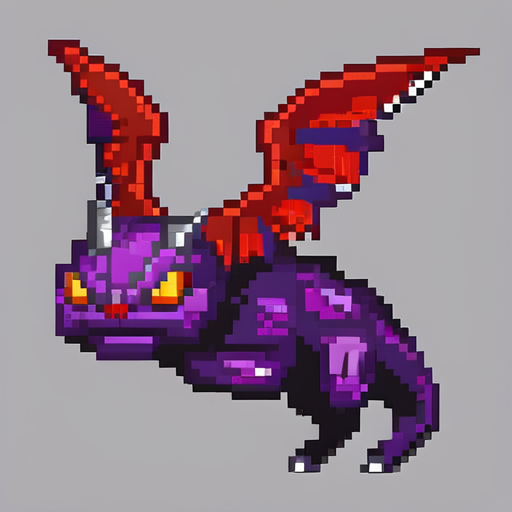

  0%|                                               | 0.00/176M [00:00<?, ?B/s]

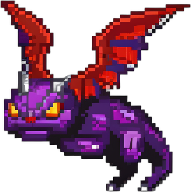

In [10]:
from IPython.display import display

meta = PROMPTS['_meta']
test_entry = PROMPTS['blacklist_v3'][0]
prompt, neg = build_prompt(test_entry, meta, 'monsters')
print(f'Prompt: {prompt[:100]}...')
print(f'Negative: {neg[:80]}...')

result = pipe(prompt=prompt, negative_prompt=neg, width=512, height=512,
              num_inference_steps=test_entry.get('steps_xl', 28),
              guidance_scale=test_entry.get('guidance_xl', 8.0))
display(result.images[0])
test_img = postprocess(result.images[0], test_entry, 'monsters')
display(test_img)
free_vram()

## 7. Generate Blacklist V3 (18 monsters)

~6–10s per sprite on T4. Output overwrites existing files in `monsters/`. After generation, copy to `public/assets/ai/monsters/` and remove entries from `AI_CONTENT_BLACKLIST` in MonsterRenderer.ts.

In [ ]:
entries = PROMPTS['blacklist_v3']
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / 'monsters'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('monsters_v3_blacklist', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\nBlacklist V3: {len(entries)} monsters, {remaining} to generate')

for i, entry in enumerate(entries):
    print(f'\n[{i+1}/{len(entries)}] {tracker.summary(len(entries))}')
    generate_one(entry, meta, 'monsters', out_dir, tracker)

print(f'\nDone! Copy from {out_dir} to public/assets/ai/monsters/')

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['aque body']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['aque body']



Blacklist V3: 18 monsters, 18 to generate

[1/18] 0/18 done
  mon_bat (192px, 26 steps)... 

  0%|          | 0/26 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


33 KB, 10.7s

[2/18] 1/18 done, ~3 min remaining
  mon_bear (192px, 26 steps)... 

...

  0%|          | 0/26 [00:00<?, ?it/s]

32 KB, 15.5s

[17/18] 16/18 done, ~0 min remaining
  mon_wolf_ice (192px, 26 steps)... 

  0%|          | 0/26 [00:00<?, ?it/s]

33 KB, 10.7s

[18/18] 17/18 done, ~0 min remaining
  mon_boss_forge_master (256px, 30 steps)... 

  0%|          | 0/30 [00:00<?, ?it/s]

## 8. (Skipped)

V3 only regenerates the 18 blacklisted monsters. Base monsters and variants are unchanged.

In [ ]:
# V3 skips base monsters — only blacklist_v3 is generated in section 7
print('Skipped. Run section 7 for blacklist regeneration.')

## 9. (Skipped)

Variants unchanged in V3.

In [ ]:
# V3 skips variants
print('Skipped.')

## 10. Quality Review

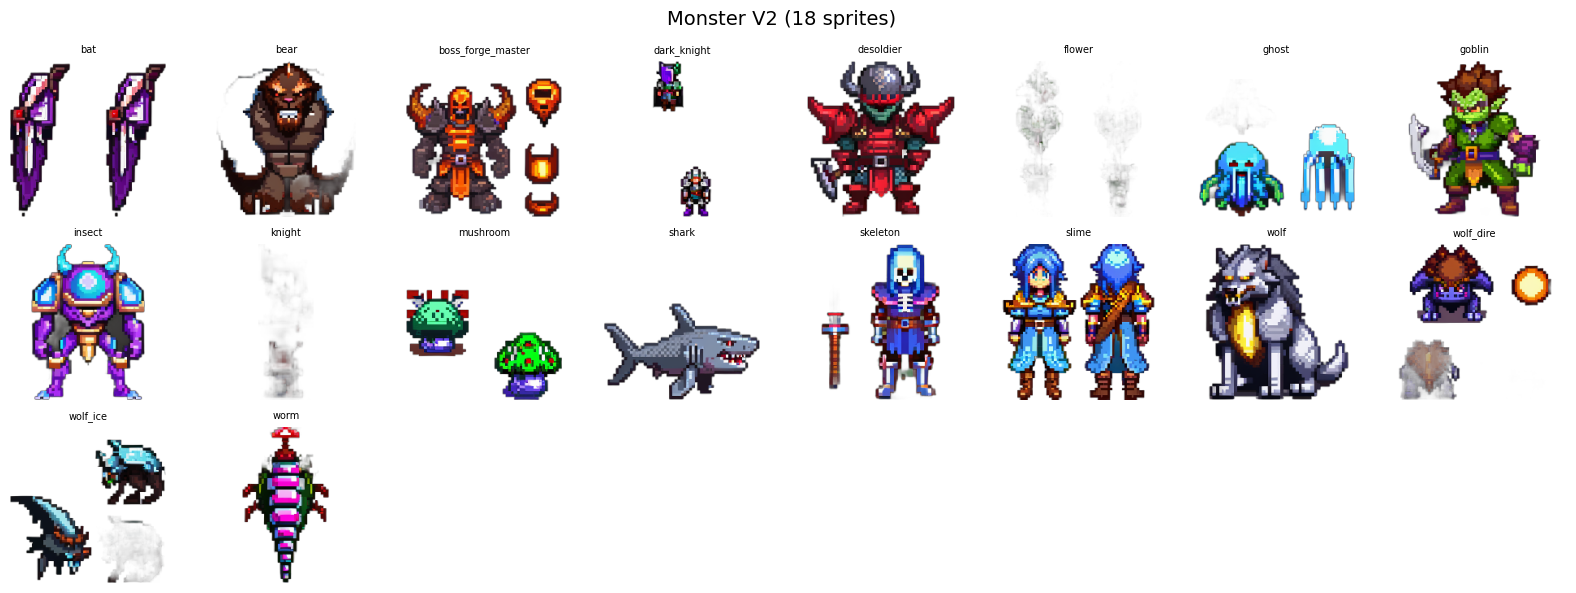

In [ ]:
import matplotlib.pyplot as plt

out_dir = OUTPUT_BASE / 'monsters'
pngs = sorted(out_dir.glob('*.png'))
pngs = [p for p in pngs if not p.stem.startswith('_')]

cols = 8
rows = (len(pngs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
for ax in axes.flat:
    ax.axis('off')

for i, png in enumerate(pngs):
    ax = axes[i // cols][i % cols] if rows > 1 else axes[i % cols]
    img = Image.open(png)
    ax.imshow(img)
    ax.set_title(png.stem.replace('mon_', ''), fontsize=7)

plt.suptitle(f'Monster V2 ({len(pngs)} sprites)', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Generate Manifest + Download

After downloading the zip:
1. Extract and copy `monsters/*.png` to `public/assets/ai/monsters/` (or use `bash scripts/import_colab_assets.sh <extracted_dir>`)
2. Remove the regenerated entries from `AI_CONTENT_BLACKLIST` in `src/art/monsters/MonsterRenderer.ts`

In [ ]:
import shutil

manifest = {}
d = OUTPUT_BASE / 'monsters'
if d.exists():
    keys = sorted(f.stem for f in d.glob('*.png') if not f.stem.startswith('_'))
    if keys:
        manifest['monsters'] = keys

manifest_path = OUTPUT_BASE / 'manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print('Manifest:')
for cat, keys in manifest.items():
    print(f'  {cat}: {len(keys)}')

zip_path = '/content/monsters_v3_output'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_BASE))
print(f'\nZip: {os.path.getsize(zip_path + ".zip") / 1024 / 1024:.1f} MB')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')